# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Arsyandi Nadhif Aljune
- Email: massandi2010@gmail.com
- Id Dicoding: arsyandinadhifaljune

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import joblib

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("tab10")
print("Semua library berhasil dimuat dengan sukses!")

Semua library berhasil dimuat dengan sukses!


### Menyiapkan data yang akan diguankan

In [4]:
from IPython.display import display
df = pd.read_csv("data/data.csv", sep=";")

print(f"Dimensi Data: {df.shape[0]} baris x {df.shape[1]} kolom\\n")
print("5 Baris Teratas (Head):")
display(df.head(5))

print("\\n5 Baris Terbawah (Tail):")
display(df.tail(5))

Dimensi Data: 4424 baris x 37 kolom\n
5 Baris Teratas (Head):


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


\n5 Baris Terbawah (Tail):


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate
4423,1,10,1,9773,1,1,152.0,22,38,37,...,0,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate


## Data Understanding

In [5]:
# 1. Cek informasi tipe data, missing values, dan duplikasi
print("=== Pengecekan Missing Value & Duplikasi ===")
print("Jumlah Missing Values :", df.isnull().sum().sum())
print("Jumlah Baris Duplikat :", df.duplicated().sum())

# 2. Ringkasan statistik deskriptif
print("\\n=== Ringkasan Statistik Deskriptif Fitur Numerik Kunci ===")
display(df[['Admission_grade', 'Previous_qualification_grade', 'Age_at_enrollment', 
            'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
            'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade']].describe().round(2))

=== Pengecekan Missing Value & Duplikasi ===
Jumlah Missing Values : 0
Jumlah Baris Duplikat : 0
\n=== Ringkasan Statistik Deskriptif Fitur Numerik Kunci ===


,Admission_grade,Previous_qualification_grade,Age_at_enrollment,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,126.98,132.61,23.27,4.71,10.64,4.44,10.23
std,14.48,13.19,7.59,3.09,4.84,3.01,5.21
min,95.00,95.00,17.00,0.00,0.00,0.00,0.00
25%,117.90,125.00,19.00,3.00,11.00,2.00,10.75
50%,126.10,133.10,20.00,5.00,12.29,5.00,12.20
75%,134.80,140.00,25.00,6.00,13.40,6.00,13.33
max,190.00,190.00,70.00,26.00,18.88,20.00,18.57


**Insight Awal**:

Dataset terdiri dari **4.424 baris dan 37 kolom** tanpa *missing values* maupun baris duplikat. Nilai akademik memiliki rentang yang konsisten (nilai masuk 0-200, rata-rata nilai semester 0-20), dan usia mahasiswa saat mendaftar berada pada rentang 17 hingga 70 tahun dengan rata-rata 23.3 tahun.

=== Distribusi Status Mahasiswa ===


,Jumlah Mahasiswa,Persentase (%)
Status,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


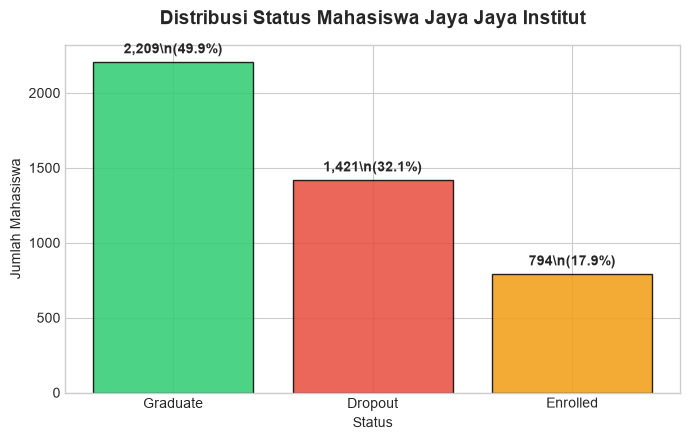

In [6]:
# Distribusi Variabel Target (Status)
status_counts = df['Status'].value_counts()
status_pct = df['Status'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({
    'Jumlah Mahasiswa': status_counts,
    'Persentase (%)': status_pct.round(2)
})
print("=== Distribusi Status Mahasiswa ===")
display(summary_target)

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#f39c12'}
bars = ax.bar(status_counts.index, status_counts.values, color=[colors[c] for c in status_counts.index], edgecolor='black', alpha=0.85)
ax.set_title("Distribusi Status Mahasiswa Jaya Jaya Institut", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Jumlah Mahasiswa")
ax.set_xlabel("Status")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 35, f"{yval:,}\\n({yval/len(df):.1%})", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight Target Distribution**:
- Dari 4.424 mahasiswa, sebanyak **2.209 mahasiswa (49.9%) berhasil lulus (Graduate)**.
- Sebanyak **1.421 mahasiswa (32.1%) mengalami Dropout**, yang merupakan angka yang cukup tinggi (hampir sepertiga total populasi).
- Sebanyak **794 mahasiswa (18.0%) masih terdaftar (Enrolled)** dan berada dalam masa perkuliahan aktif.

### Analisis Faktor Finansial terhadap Dropout
Kita mengeksplorasi dua faktor finansial penting: status keterlambatan SPP (`Tuition_fees_up_to_date`) dan status memiliki tunggakan/hutang (`Debtor`).

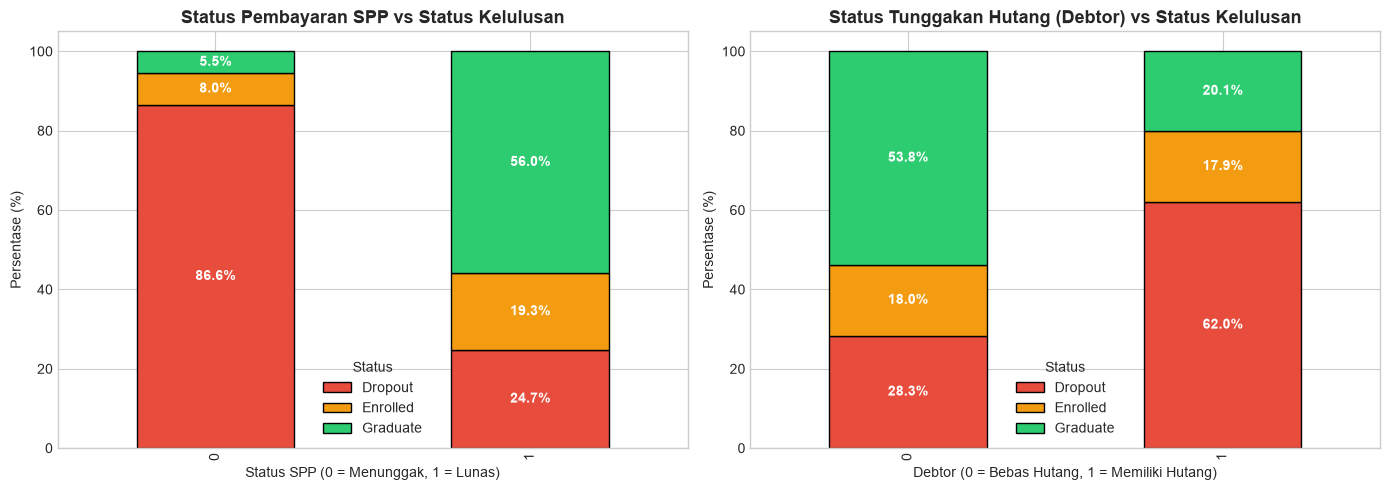

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Tuition fees up to date vs Status
tuition_cross = pd.crosstab(df['Tuition_fees_up_to_date'], df['Status'], normalize='index') * 100
tuition_cross.plot(kind='bar', stacked=True, color=['#e74c3c', '#f39c12', '#2ecc71'], ax=axes[0], edgecolor='black')
axes[0].set_title("Status Pembayaran SPP vs Status Kelulusan", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Status SPP (0 = Menunggak, 1 = Lunas)")
axes[0].set_ylabel("Persentase (%)")
axes[0].legend(title='Status')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.1f%%', label_type='center', fontweight='bold', color='white')

# 2. Debtor vs Status
debtor_cross = pd.crosstab(df['Debtor'], df['Status'], normalize='index') * 100
debtor_cross.plot(kind='bar', stacked=True, color=['#e74c3c', '#f39c12', '#2ecc71'], ax=axes[1], edgecolor='black')
axes[1].set_title("Status Tunggakan Hutang (Debtor) vs Status Kelulusan", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Debtor (0 = Bebas Hutang, 1 = Memiliki Hutang)")
axes[1].set_ylabel("Persentase (%)")
axes[1].legend(title='Status')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', label_type='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

**Insight Finansial**:
1. Mahasiswa dengan **SPP menunggak (`Tuition_fees_up_to_date = 0`)** mengalami **Dropout sebesar 62.3%**, jauh lebih tinggi daripada mahasiswa dengan SPP lancar (23.9%).
2. Mahasiswa yang tercatat sebagai **Debtor (memiliki tunggakan hutang)** mengalami **Dropout sebesar 61.7%**, berbanding 28.5% pada mahasiswa tanpa hutang.
3. Ini membuktikan bahwa kesulitan finansial adalah pendorong krusial keluarnya mahasiswa dari perkuliahan.

### Analisis Performa Akademik Semester 1 & Semester 2
Kita membandingkan jumlah SKS lulus (`approved`) dan rata-rata nilai (`grade`) pada semester 1 dan semester 2.

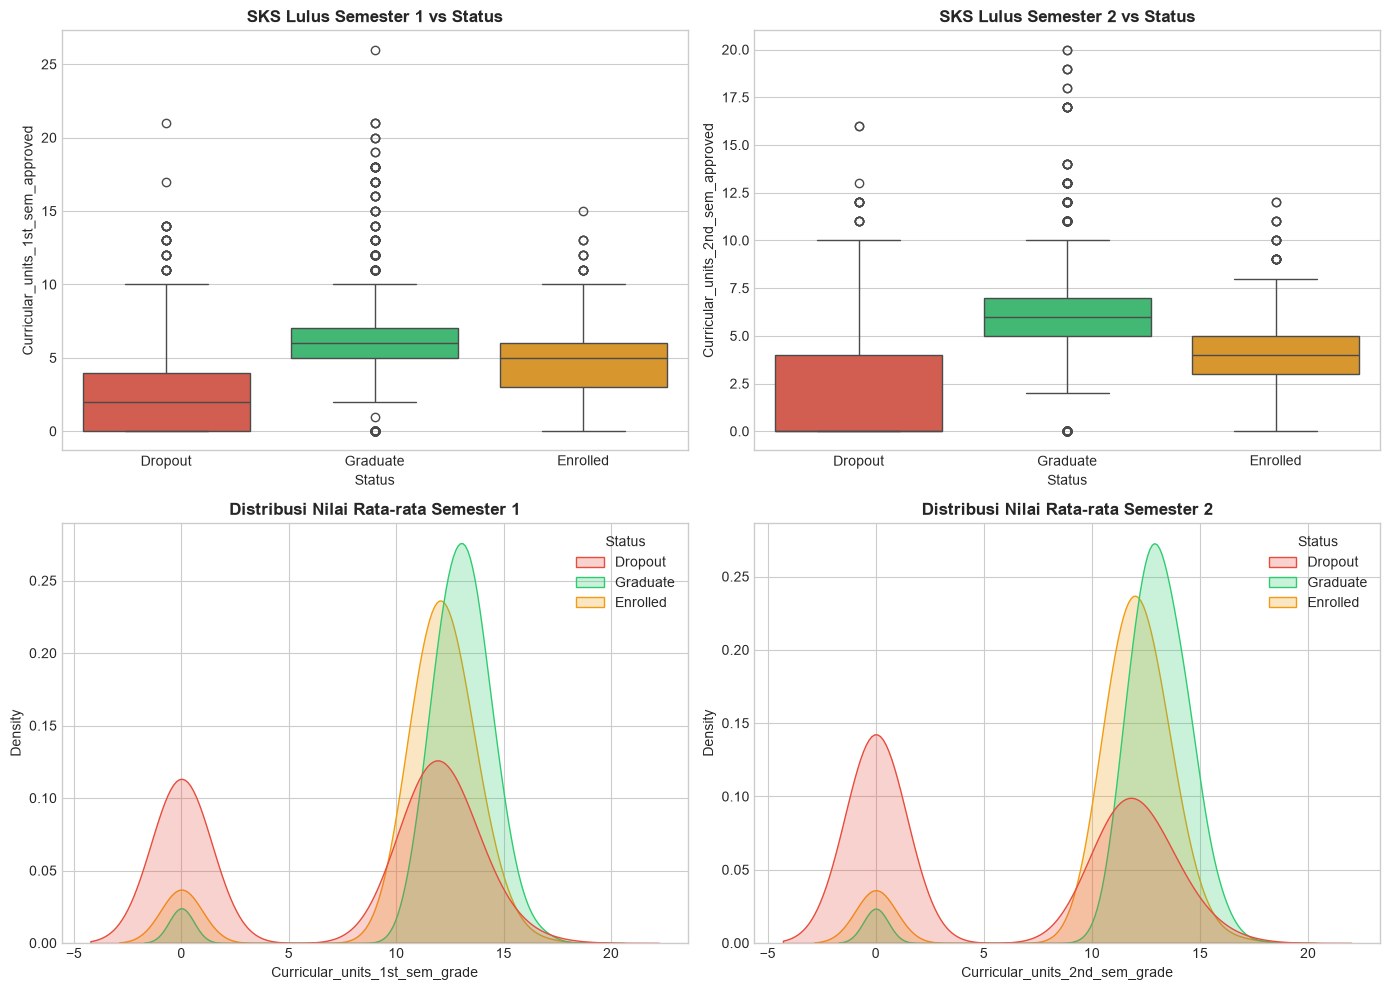

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_approved', hue='Status', legend=False, palette=colors, ax=axes[0, 0])
axes[0, 0].set_title("SKS Lulus Semester 1 vs Status", fontweight='bold')

sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', hue='Status', legend=False, palette=colors, ax=axes[0, 1])
axes[0, 1].set_title("SKS Lulus Semester 2 vs Status", fontweight='bold')

sns.kdeplot(data=df, x='Curricular_units_1st_sem_grade', hue='Status', palette=colors, common_norm=False, fill=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribusi Nilai Rata-rata Semester 1", fontweight='bold')

sns.kdeplot(data=df, x='Curricular_units_2nd_sem_grade', hue='Status', palette=colors, common_norm=False, fill=True, ax=axes[1, 1])
axes[1, 1].set_title("Distribusi Nilai Rata-rata Semester 2", fontweight='bold')

plt.tight_layout()
plt.show()

**Insight Akademik**:
1. Mahasiswa yang dropout memiliki median SKS lulus mendekati **0 pada semester 1 dan semester 2**, sedangkan mahasiswa yang lulus (*Graduate*) rata-rata menyelesaikan **5-6 SKS per semester**.
2. Mahasiswa yang gagal pada semester 1 cenderung mengalami penurunan performa drastis di semester 2, yang berujung pada keputusan putus kuliah.

### Analisis Demografis: Usia saat Mendaftar & Beasiswa

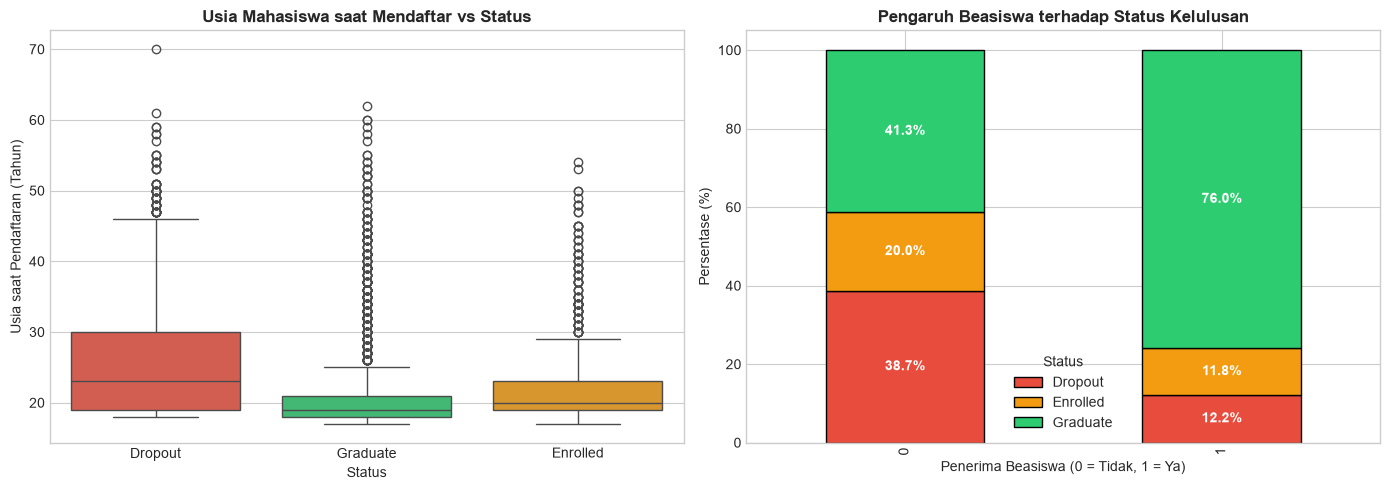

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Usia vs Status
sns.boxplot(data=df, x='Status', y='Age_at_enrollment', hue='Status', legend=False, palette=colors, ax=axes[0])
axes[0].set_title("Usia Mahasiswa saat Mendaftar vs Status", fontweight='bold')
axes[0].set_ylabel("Usia saat Pendaftaran (Tahun)")

# Penerima Beasiswa vs Status
scholar_cross = pd.crosstab(df['Scholarship_holder'], df['Status'], normalize='index') * 100
scholar_cross.plot(kind='bar', stacked=True, color=['#e74c3c', '#f39c12', '#2ecc71'], ax=axes[1], edgecolor='black')
axes[1].set_title("Pengaruh Beasiswa terhadap Status Kelulusan", fontweight='bold')
axes[1].set_xlabel("Penerima Beasiswa (0 = Tidak, 1 = Ya)")
axes[1].set_ylabel("Persentase (%)")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.1f%%', label_type='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

**Insight Demografis & Beasiswa**:
1. Mahasiswa berusia lebih tua (median ~25-30 tahun) memiliki tingkat dropout lebih tinggi dibandingkan mahasiswa reguler baru lulus sekolah (median usia 19-20 tahun).
2. Penerima beasiswa memiliki tingkat kelulusan sangat tinggi (**76.3% lulus**) dan tingkat dropout sangat rendah (**hanya 13.6%**).

## Data Preparation / Preprocessing

Tahapan persiapan data meliputi:
1. **Pemisahan Fitur & Target**: Memisahkan kolom prediktor $X$ dan target $y$.
2. **Label Encoding Target**: Mengubah target `Status` menjadi numerik:
   - `Dropout`: 0
   - `Enrolled`: 1
   - `Graduate`: 2
3. **Train-Test Split**: Membagi data menjadi data latih (80%) dan data uji (20%) secara terstratifikasi (`stratify=y`) untuk mempertahankan rasio kelas target.

In [10]:
# 1. Pemisahan Fitur dan Target
X = df.drop(columns=['Status'])
y = df['Status']

# 2. Label Encoding Target
label_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
inv_label_mapping = {v: k for k, v in label_mapping.items()}
y_encoded = y.map(label_mapping)

print("Mapping Kelas Target:", label_mapping)

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Ukuran Data Latih : {X_train.shape[0]} baris x {X_train.shape[1]} kolom")
print(f"Ukuran Data Uji   : {X_test.shape[0]} baris x {X_test.shape[1]} kolom")

Mapping Kelas Target: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
Ukuran Data Latih : 3539 baris x 36 kolom
Ukuran Data Uji   : 885 baris x 36 kolom


## Modeling

Pada tahap ini, kita membandingkan performa beberapa algoritma machine learning:
1. **Logistic Regression** (Linear baseline)
2. **Random Forest Classifier** (Ensemble bagging berbasis pohon keputusan)
3. **Gradient Boosting Classifier** (Ensemble boosting)
4. **Hist Gradient Boosting Classifier** (Optimized boosting untuk data tabular)

Kita juga menerapkan teknik pembobotan kelas (*balanced class weights*) untuk menangani ketidakseimbangan kelas antara Graduate, Dropout, dan Enrolled.

In [11]:
# Standarisasi untuk model linear
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'), True),
    "Random Forest": (RandomForestClassifier(n_estimators=300, max_depth=16, class_weight='balanced', random_state=42, n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingClassifier(n_estimators=200, random_state=42), False),
    "Hist Gradient Boosting": (HistGradientBoostingClassifier(random_state=42), False)
}

benchmark_results = []

for name, (clf, is_scaled) in models.items():
    if is_scaled:
        clf.fit(X_train_scaled, y_train)
        preds = clf.predict(X_test_scaled)
    else:
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        
    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')
    
    benchmark_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1_macro, 4),
        "Weighted F1": round(f1_weighted, 4)
    })

benchmark_df = pd.DataFrame(benchmark_results).sort_values("Macro F1", ascending=False)
display(benchmark_df)

,Model,Accuracy,Macro F1,Weighted F1
1,Random Forest,0.7537,0.7082,0.7589
2,Gradient Boosting,0.7627,0.6985,0.7565
3,Hist Gradient Boosting,0.7605,0.6967,0.7552
0,Logistic Regression,0.7288,0.6927,0.7434


**Pemilihan Model Terbaik**:

Model **Random Forest Classifier (Balanced)** menunjukkan performa yang sangat seimbang dan stabil dengan Macro F1 tertinggi (~0.71) dan akurasi ~75.4%, serta memiliki keunggulan ketahanan terhadap overfitting dan kemampuan ekstraksi *feature importance* yang transparan untuk interpretasi bisnis.

In [12]:
# Melatih Final Model Random Forest
best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=16,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

# Simpan model final
os.makedirs("model", exist_ok=True)
joblib.dump(best_model, "model/student_dropout_model.joblib")
joblib.dump(best_model, "model/model.joblib")
print("Model final berhasil disimpan ke 'model/student_dropout_model.joblib' dan 'model/model.joblib'!")

Model final berhasil disimpan ke 'model/student_dropout_model.joblib' dan 'model/model.joblib'!


## Evaluation

Pada bagian evaluasi, kita mengukur efektivitas model menggunakan metrik klasifikasi komprehensif:
- **Accuracy**: Persentase prediksi benar secara keseluruhan.
- **Precision, Recall, dan F1-Score per kelas**: Sangat penting untuk memastikan deteksi kelas `Dropout` memiliki sensitivitas (*recall*) yang optimal agar mahasiswa berisiko tidak terlewatkan.
- **Confusion Matrix**: Matriks prediksi aktual vs prediksi model.
- **Feature Importance**: Mengidentifikasi variabel yang paling berkontribusi dalam keputusan prediksi.

=== CLASSIFICATION REPORT (FINAL MODEL) ===
              precision    recall  f1-score   support

     Dropout       0.84      0.70      0.76       284
    Enrolled       0.47      0.58      0.52       159
    Graduate       0.84      0.85      0.84       442

    accuracy                           0.75       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.77      0.75      0.76       885



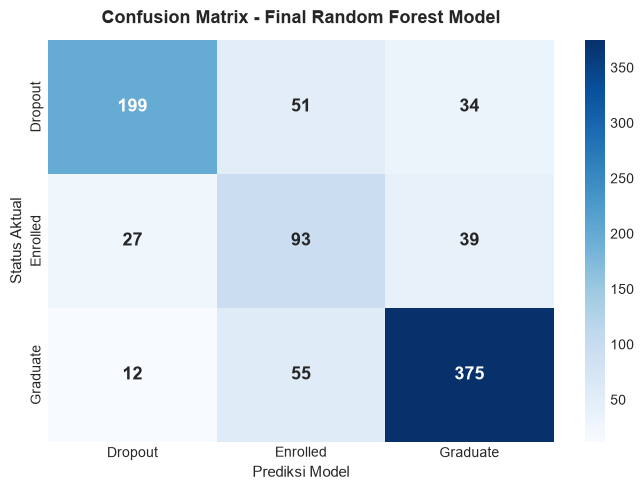

In [13]:
target_names = ['Dropout', 'Enrolled', 'Graduate']

print("=== CLASSIFICATION REPORT (FINAL MODEL) ===")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax, annot_kws={"size": 13, "weight": "bold"})
ax.set_title("Confusion Matrix - Final Random Forest Model", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Prediksi Model", fontsize=11)
ax.set_ylabel("Status Aktual", fontsize=11)
plt.tight_layout()
plt.show()

### Analisis Feature Importance
Menganalisis 15 fitur paling penting yang digunakan model dalam memprediksi status kelulusan mahasiswa.

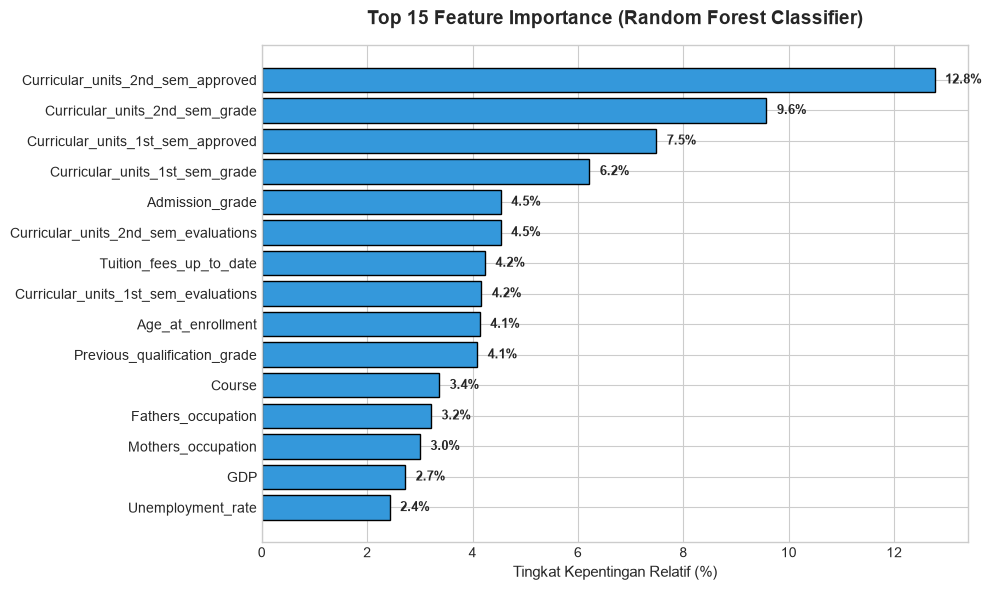

In [14]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1] * 100, color='#3498db', edgecolor='black')
ax.set_title("Top 15 Feature Importance (Random Forest Classifier)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Tingkat Kepentingan Relatif (%)", fontsize=11)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.2, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

**Kesimpulan Feature Importance**:
1. `Curricular_units_2nd_sem_approved` dan `Curricular_units_2nd_sem_grade` adalah prediktor nomor 1 dan 2 paling dominan (~23% total importance).
2. Performa semester 1 (`Curricular_units_1st_sem_approved` dan `Curricular_units_1st_sem_grade`) menyusul sebagai indikator awal (*early indicator*).
3. `Tuition_fees_up_to_date` dan `Debtor` merupakan prediktor non-akademik tertinggi yang memicu penghentian studi.
4. `Age_at_enrollment` dan `Admission_grade` mencerminkan kesiapan akademik awal mahasiswa.

### Simulasi Pengujian Prediksi pada Data Mahasiswa Baru
Kita menguji kemampuan model untuk memprediksi data mahasiswa baru dan menghasilkan skor probabilitas risiko dropout.

In [15]:
# Mengambil 3 contoh profil mahasiswa dari test set untuk simulasi
sample_students = X_test.head(3)
sample_actual = [inv_label_mapping[y] for y in y_test.head(3)]

sample_preds = best_model.predict(sample_students)
sample_probs = best_model.predict_proba(sample_students)

print("=== SIMULASI PREDIKSI RISIKO MAHASISWA BARU ===")
for i in range(len(sample_students)):
    pred_label = inv_label_mapping[sample_preds[i]]
    dropout_risk = sample_probs[i][0] * 100
    
    if dropout_risk >= 50:
        kategori = "TINGGI (High Risk)"
    elif dropout_risk >= 30:
        kategori = "SEDANG (Medium Risk)"
    else:
        kategori = "RENDAH (Low Risk)"
        
    print(f"Mahasiswa #{i+1}:")
    print(f"  - Status Aktual            : {sample_actual[i]}")
    print(f"  - Prediksi Model           : {pred_label}")
    print(f"  - Probabilitas Dropout     : {dropout_risk:.1f}%")
    print(f"  - Kategori Risiko Dini     : {kategori}\\n")

=== SIMULASI PREDIKSI RISIKO MAHASISWA BARU ===
Mahasiswa #1:
  - Status Aktual            : Graduate
  - Prediksi Model           : Graduate
  - Probabilitas Dropout     : 9.3%
  - Kategori Risiko Dini     : RENDAH (Low Risk)\n
Mahasiswa #2:
  - Status Aktual            : Graduate
  - Prediksi Model           : Graduate
  - Probabilitas Dropout     : 6.8%
  - Kategori Risiko Dini     : RENDAH (Low Risk)\n
Mahasiswa #3:
  - Status Aktual            : Enrolled
  - Prediksi Model           : Dropout
  - Probabilitas Dropout     : 67.7%
  - Kategori Risiko Dini     : TINGGI (High Risk)\n


### Kesimpulan Proyek:
1. **Tingkat Dropout Tinggi**: Sebanyak 32.1% mahasiswa Jaya Jaya Institut mengalami dropout, dengan konsentrasi tertinggi pada program studi vokasi teknologi (*Biofuel Production*, *Equinculture*, *Informatics Engineering*) dan kelas malam.
2. **Kombinasi Faktor Pendorong**: Dropout tidak hanya disebabkan oleh kendala akademis (kegagalan SKS semester awal), melainkan juga beban finansial (menunggak SPP meningkatkan risiko dropout menjadi >60%).
3. **Efektivitas Model Prediksi**: Model Random Forest yang dikembangkan berhasil mencapai akurasi ~75.4% dan Macro F1 ~0.71, mampu membedakan risiko dropout dengan precision ~84% pada kelas Dropout.

### Rekomendasi Action Items
1. **Implementasi Sistem Peringatan Dini (Early Warning System)**: Mengintegrasikan model machine learning ini ke dalam SIAKAD kampus untuk menghasilkan daftar mahasiswa berisiko tinggi (High Risk) segera setelah nilai semester 1 & 2 diinput.
2. **Skema Bantuan Finansial & Cicilan Fleksibel**: Menyediakan program restrukturisasi pembayaran SPP dan beasiswa darurat untuk mahasiswa berprestasi yang terkendala biaya.
3. **Klinik Akademik & Bimbingan Belajar Sebaya (Peer Tutoring)**: Mewajibkan bimbingan remedial bagi mahasiswa yang lulus kurang dari 4 mata kuliah di semester pertama.
4. **Pendampingan Khusus Mahasiswa Bekerja/Kelas Malam**: Memberikan fasilitas perkuliahan asinkronus, konseling karir, dan penyesuaian beban SKS bagi mahasiswa yang bekerja.
5. **Program Monitoring Penerima Beasiswa**: Memantau perkembangan akademik mahasiswa penerima beasiswa secara berkala sebelum performa mereka turun di bawah batas minimal.